# Error analysis and calibration

**Learning objective:** Go beyond accuracy with a confusion matrix, per-class error rates and expected calibration error.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:16:28.584690: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974988.600390    4275 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974988.604714    4275 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:16:30.312709: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
from sklearn.metrics import confusion_matrix, accuracy_score
(x,y),(xt,yt)=tf.keras.datasets.fashion_mnist.load_data(); x=x[:5000,...,None].astype("float32")/255; y=y[:5000]; xt=xt[:1500,...,None].astype("float32")/255; yt=yt[:1500]
model=tf.keras.Sequential([tf.keras.layers.Input((28,28,1)),tf.keras.layers.Conv2D(16,3,activation="relu"),tf.keras.layers.MaxPooling2D(),tf.keras.layers.GlobalAveragePooling2D(),tf.keras.layers.Dense(10,activation="softmax")]); model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"]); model.fit(x,y,epochs=2,batch_size=64,verbose=0)
prob=model.predict(xt,verbose=0); pred=prob.argmax(1); cm=confusion_matrix(yt,pred); print("accuracy:",round(accuracy_score(yt,pred),4))


accuracy: 0.148


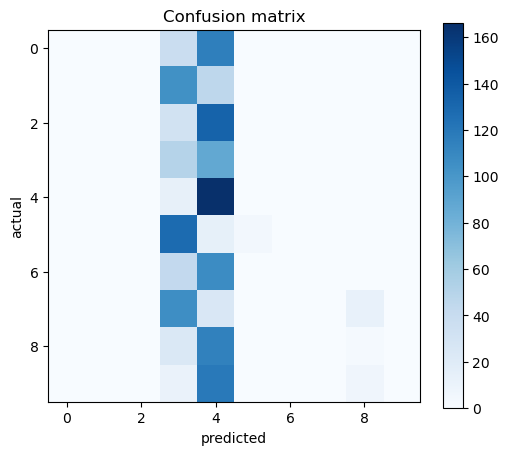

10-bin expected calibration error: 0.0258
mean confidence: 0.1222 accuracy: 0.148


In [3]:
plt.figure(figsize=(6,5)); plt.imshow(cm,cmap="Blues"); plt.colorbar(); plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix"); plt.show()
conf=prob.max(1); correct=(pred==yt).astype(float); bins=np.linspace(0,1,11); ece=0
for lo,hi in zip(bins[:-1],bins[1:]):
    m=(conf>=lo)&(conf<hi)
    if m.any(): ece += m.mean()*abs(correct[m].mean()-conf[m].mean())
print("10-bin expected calibration error:",round(float(ece),4)); print("mean confidence:",round(float(conf.mean()),4),"accuracy:",round(float(correct.mean()),4))


Calibration asks whether a prediction reported at 80% confidence is correct about 80% of the time. A model can be accurate yet overconfident.
